# Corporate Geopolitical Risk Index (CGRI) — Methodology Notebook

Implements and validates the CGRI framework from the Excel files in `data/processed/`.

## Formula

$$
CGRI = \left( 0.20 \cdot HQ_{Risk} + 0.40 \cdot Rev_{Exp} + 0.40 \cdot SC_{Exp} \right) \times S \times V \times F_{lev}
$$

| Symbol | Component | Formula | HHI? |
|---|---|---|---|
| $HQ_{Risk}$ | HQ Country Risk | Country GRI of HQ location | — |
| $Rev_{Exp}$ | Revenue Exposure | $\sum GRI_c \times rev_c \times HHI_{sub}$ | ✓ |
| $SC_{Exp}$ | Supply Chain | $(0.5 \times C_{sup} + 0.5 \times C_{fac}) \times HHI_{sub}$ | ✓ |
| $S$ | Sector Multiplier | S&P Global Industry Risk Assessment | — |
| $V$ | Volatility Multiplier | $1 + \Delta\%$ vs long-run VIX average | — |
| $F_{lev}$ | Financial Leverage | 0.8 / 0.9 / 1.0 / 1.1 from Net Debt / EBITDA | — |


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from openpyxl import load_workbook

NOTEBOOK_DIR = Path('.').resolve()
DATA_DIR     = NOTEBOOK_DIR.parent / 'data' / 'processed'
assert DATA_DIR.exists(), f'Not found: {DATA_DIR}'
print('Data dir:', DATA_DIR)

Data dir: /Users/arzumkarahan/Desktop/DSBA/2nd year/Geopolitics/Group Project/company-geopolitical-risk-index/data/processed


## 1. Load reference data

In [2]:
def ws(path, sheet):
    return load_workbook(path, data_only=True)[sheet]

# 1a. Country GRI (147 countries)
_ws = ws(DATA_DIR/'HQ Country Risk Index.xlsx', 'Geopolitical Risk Index')
rows = []
for r in range(2, _ws.max_row + 1):
    c, s = _ws.cell(r,1).value, _ws.cell(r,2).value
    if c and isinstance(s, (int,float)):
        rows.append({'Country': str(c).strip(), 'GRI': float(s)})

country_df  = pd.DataFrame(rows).drop_duplicates('Country').sort_values('Country').reset_index(drop=True)
country_gri = dict(zip(country_df['Country'], country_df['GRI']))

# Taiwan not in GRI dataset (political status) — use value from Excel HQ sheet (4.26)
country_gri['Taiwan'] = 4.26

print(f'Countries loaded: {len(country_gri)}  (Taiwan added = 4.26)')
country_df.head(6)

Countries loaded: 148  (Taiwan added = 4.26)


,Country,GRI
0,Albania,4.37
1,Algeria,5.21
2,Angola,5.63
3,Argentina,4.36
4,Armenia,4.79
5,Australia,3.22


In [3]:
# 1b. Sector multipliers
_ws = ws(DATA_DIR/'Sector Risk Multiplier.xlsx', 'Sector Risk Multiplier')
sec_rows = []
for r in range(5, _ws.max_row + 1):
    co, se, la, mu = _ws.cell(r,4).value, _ws.cell(r,5).value, _ws.cell(r,6).value, _ws.cell(r,8).value
    if co and se and isinstance(mu, (int,float)):
        sec_rows.append({'company': str(co).strip(), 'sector': str(se).strip(),
                         'sp_label': str(la).strip() if la else '', 'multiplier': float(mu)})
sector_df   = pd.DataFrame(sec_rows)
sector_mult = dict(zip(sector_df['sector'], sector_df['multiplier']))

co_sector = dict(zip(sector_df['company'], sector_df['sector']))
# Canonical aliases (Final Template names differ from sector sheet names for 2 companies)
co_sector['Total Energies'] = co_sector.get('Totale Energies', 'Oil and gas exploration and production')

print(f'Sectors: {len(sector_df)} companies, {len(sector_mult)} unique sectors')
sector_df[['company','sector','sp_label','multiplier']]

Sectors: 25 companies, 10 unique sectors


,company,sector,sp_label,multiplier
0,Allianz,Insurance (Financial services),Moderately high risk,1.10
1,Amazon,Retail and restaurants,Intermediate risk,1.00
2,Apple,Technology hardware and semiconductors,Moderately high risk,1.10
3,ASML,Technology hardware and semiconductors,Moderately high risk,1.10
4,BNP Paribas,Financial services finance companies,Moderately high risk,1.10
5,Eli Lilly,Pharmaceuticals,Low risk,0.85
6,ENI,Oil and gas exploration and production,Moderately high risk,1.10
7,Ford,Auto and commercial vehicle manufacturing,Moderately high risk,1.10
8,JP Morgan,Financial services finance companies,Moderately high risk,1.10
9,L'Oreal,Consumer staples and branded nondurables,Low risk,0.85


In [4]:
# 1c. Benchmark results (Final Template - 2024)
_ws = ws(DATA_DIR/'Template CGRI.xlsx', 'Final Template - 2024')
bench_rows = []
for r in range(3, _ws.max_row + 1):
    co = _ws.cell(r,1).value
    if co is None: continue
    try:
        bench_rows.append({
            'Company':               str(co).strip(),
            'HQ Risk':               float(_ws.cell(r,2).value),
            'Revenue Exposure':      float(_ws.cell(r,3).value),
            'Supply Chain':          float(_ws.cell(r,4).value),
            'Financial Multiplier':  float(_ws.cell(r,5).value),
            'Sector Multiplier':     float(_ws.cell(r,6).value),
            'Volatility Multiplier': float(_ws.cell(r,7).value),
            'Final CGRI':            float(_ws.cell(r,8).value),
        })
    except (TypeError, ValueError):
        continue

bench_df = pd.DataFrame(bench_rows)
bench_df['Sector'] = bench_df['Company'].map(co_sector).fillna('Unknown')

def risk_label(s):
    if s < 3.5: return 'Low'
    if s < 5.0: return 'Moderate'
    if s < 6.5: return 'High'
    return 'Very High'

def risk_color(s):
    return {'Low':'#27ae60','Moderate':'#f39c12','High':'#e67e22','Very High':'#e74c3c'}[risk_label(s)]

RISK_COLORS = {'Low':'#27ae60','Moderate':'#f39c12','High':'#e67e22','Very High':'#e74c3c'}
bench_df['Risk Category'] = bench_df['Final CGRI'].apply(risk_label)
bench_df = bench_df.sort_values('Final CGRI', ascending=False).reset_index(drop=True)
print(f'Benchmark companies: {len(bench_df)}')
bench_df[['Company','Sector','Risk Category','Final CGRI']]


Benchmark companies: 25


,Company,Sector,Risk Category,Final CGRI
0,Reliance Industries,Oil and gas exploration and production,High,5.779320
1,TSMC,Technology hardware and semiconductors,Moderate,4.494566
2,NVIDIA,Technology hardware and semiconductors,Moderate,4.359709
3,Amazon,Retail and restaurants,Moderate,4.300894
4,Ford,Auto and commercial vehicle manufacturing,Moderate,4.187754
5,BNP Paribas,Financial services finance companies,Moderate,4.183671
6,Tencent,Technology software and services,Moderate,4.096763
7,Microsoft,Technology software and services,Moderate,4.084603
8,Apple,Technology hardware and semiconductors,Moderate,3.996190
9,ASML,Technology hardware and semiconductors,Moderate,3.916267


In [5]:
# 1d. HQ country lookup
_ws = ws(DATA_DIR/'HQ Country Risk Index.xlsx', 'HQ Country Risk Index')
hq_map = {}
for r in range(2, _ws.max_row + 1):
    co, hq = _ws.cell(r,1).value, _ws.cell(r,2).value
    if co and hq:
        hq_map[str(co).strip()] = str(hq).strip()
# Alias: HQ sheet uses 'Totale Energies', canonical is 'Total Energies'
hq_map['Total Energies'] = hq_map.get('Totale Energies', 'France')

# 1e. Net Debt/EBITDA (used to derive Financial Leverage Multiplier)
_ws = ws(DATA_DIR/'Template CGRI.xlsx', 'Financial Exposure')
fin_map = {}
for r in range(2, _ws.max_row + 1):
    co, nd = _ws.cell(r,1).value, _ws.cell(r,2).value
    if co and isinstance(nd, (int,float)):
        fin_map[str(co).strip()] = float(nd)
fin_map['Meta']             = fin_map.get('META',          fin_map.get('Meta', 0))
fin_map['Procter & Gamble'] = fin_map.get('P&G',           fin_map.get('Procter & Gamble', 0))
fin_map['Total Energies']   = fin_map.get('Total Energies',fin_map.get('Totale Energies', 0))

print('HQ map sample:', dict(list(hq_map.items())[:5]))
print('Financial map sample:', dict(list(fin_map.items())[:5]))


HQ map sample: {'Apple': 'United States', 'Meta': 'United States', 'Microsoft': 'United States', 'Ford': 'United States', 'Procter & Gamble': 'United States'}
Financial map sample: {'Allianz': 1.45, 'Amazon': 0.35, 'Apple': -0.35, 'ASML': -0.72, 'BNP Paribas': 5.1}


2024 Volatility Multiplier: 0.934828


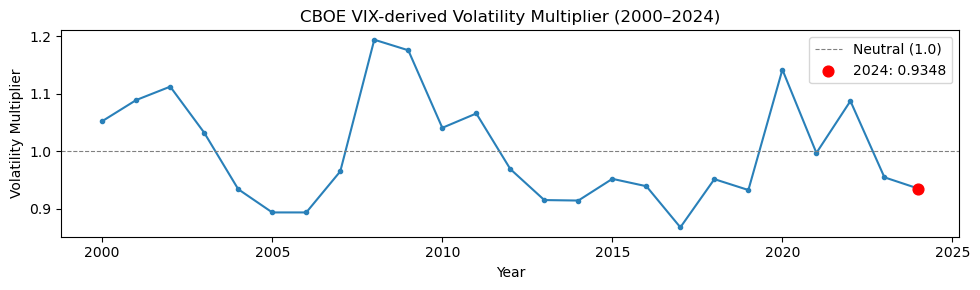

In [6]:
# 1f. Volatility Multiplier (2024)
_ws  = ws(DATA_DIR/'Template CGRI.xlsx', 'Volatility Risk Multiplier')
vol_mult = None
vol_rows = []
for r in range(5, _ws.max_row + 1):
    yr, vix_a, lt_a, delta, mu = (_ws.cell(r,4).value, _ws.cell(r,5).value,
                                   _ws.cell(r,6).value, _ws.cell(r,7).value, _ws.cell(r,8).value)
    if isinstance(yr, int) and isinstance(mu, (int,float)):
        vol_rows.append({'Year':yr,'VIX Avg':vix_a,'LT Avg':lt_a,'Delta%':delta,'Multiplier':float(mu)})
        if yr == 2024:
            vol_mult = float(mu)
vol_df = pd.DataFrame(vol_rows)
print(f'2024 Volatility Multiplier: {vol_mult:.6f}')

fig, ax = plt.subplots(figsize=(10,3))
ax.plot(vol_df['Year'], vol_df['Multiplier'], marker='o', markersize=3, linewidth=1.5, color='#2980b9')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Neutral (1.0)')
ax.scatter([2024],[vol_mult],color='red',zorder=5,s=60,label=f'2024: {vol_mult:.4f}')
ax.set_xlabel('Year'); ax.set_ylabel('Volatility Multiplier')
ax.set_title('CBOE VIX-derived Volatility Multiplier (2000–2024)')
ax.legend(); plt.tight_layout(); plt.show()

## 2. Explicit sheet-name mapping

Each Excel file uses slightly different abbreviations for company names.
This dict resolves every mismatch.

In [7]:
SHEET_MAP = {
    'Allianz':            {'rev':'Country of Revenues - Allianz',   'sc':'Country of Suppliers - Allianz'},
    'Amazon':             {'rev':'Country of Revenues - Amazon',    'sc':'Country of Suppliers - Amazon'},
    'Apple':              {'rev':'Country of Revenues - Apple',     'sc':'Country of Suppliers - Apple'},
    'ASML':               {'rev':'Country of Revenues - ASML',      'sc':'Country of Suppliers - ASML'},
    'BNP Paribas':        {'rev':'Country of Revenues - BNP',       'sc':'Country of Suppliers - BNP'},
    'Eli Lilly':          {'rev':'Country of Revenues - Eli LIlly', 'sc':'Country of Suppliers - EliLilly'},
    'ENI':                {'rev':'Country of Revenues - ENI',       'sc':'Country of Suppliers - ENI'},
    'Ford':               {'rev':'Country of Revenues - Ford',      'sc':'Country of Suppliers - Ford'},
    'JP Morgan':          {'rev':'Country of Revenues - JP Morgan', 'sc':'Country of Suppliers - JPMorgan'},
    "L'Oreal":            {'rev':'Country of Revenues - Oreal',     'sc':"Country of Suppliers - Oreal"},
    'LVMH':               {'rev':'Country of Revenues - LVMH',      'sc':'Country of Suppliers - LVMH'},
    'Meta':               {'rev':'Country of Revenues - Meta',      'sc':'Country of Suppliers - Meta'},
    'Microsoft':          {'rev':'Country of Revenues - Microsoft', 'sc':'Country of Suppliers Microsoft'},
    'Novo Nordisk':       {'rev':'Country of Revenues - Nordisk',   'sc':'Country of Suppliers - Nordisk'},
    'NVIDIA':             {'rev':'Country of Revenues - NVIDIA',    'sc':'Country of Suppliers - NVIDIA'},
    'Procter & Gamble':   {'rev':'Country of Revenues - P&G',       'sc':'Country of Suppliers - P&G'},
    'Reliance Industries':{'rev':'Country of Revenues - Reliance',  'sc':'Country of Suppliers - Reliance'},
    'Samsung':            {'rev':'Country of Revenues - Samsung',   'sc':'Country of Suppliers - Samsung'},
    'SAP':                {'rev':'Country of Revenues - SAP',       'sc':'Country of Suppliers - SAP'},
    'Sony':               {'rev':'Country of Revenues - Sony',      'sc':'Country of Suppliers - Sony'},
    'Tencent':            {'rev':'Country of Revenues - Tencent',   'sc':'Country of Suppliers - Tencent'},
    'Total Energies':     {'rev':'Country of Revenues - Total En',  'sc':'Country of Suppliers - Total En'},
    'Toyota':             {'rev':'Country of Revenues - Toyota',    'sc':'Country of Suppliers - Toyota'},
    'TSMC':               {'rev':'Country of Revenues - TSMC',      'sc':'Country of Suppliers - TSMC'},
    'Volkswagen':         {'rev':'Country of Revenues - VW',        'sc':'Country of Suppliers - VW'},
}
print(f'Sheet map: {len(SHEET_MAP)} companies')


Sheet map: 25 companies


## 3. Core computation functions

In [8]:
def normalize(d: dict) -> dict:
    """Keep only valid countries, drop TOTAL/non-country rows, normalise to sum=1."""
    clean = {str(k).strip(): float(v) for k,v in d.items()
             if k and str(k).strip() in country_gri and float(v) > 0}
    total = sum(clean.values())
    return {k: v/total for k,v in clean.items()} if total > 0 else {}

def w_gri(shares: dict) -> float:
    return sum(country_gri[c]*w for c,w in shares.items())

def hhi(shares: dict) -> float:
    return sum(w**2 for w in shares.values())

def hhi_sub(h: float) -> float:
    if h < 0.15: return 0.90
    if h < 0.25: return 1.00
    if h < 0.40: return 1.10
    if h < 0.60: return 1.25
    return 1.50

def net_debt_multiplier(r: float) -> float:
    """Financial Leverage Multiplier from Net Debt / EBITDA."""
    if r < 0: return 0.8
    if r < 2: return 0.9
    if r < 4: return 1.0
    return 1.1

def rev_exposure(rev: dict) -> dict:
    std = normalize(rev); mid = w_gri(std); h = hhi(std); sub = hhi_sub(h)
    return {'intermediate':mid,'hhi':h,'hhi_sub':sub,'final':mid*sub}

def sc_exposure(sup: dict, supfac: dict) -> dict:
    sup_std = normalize(sup); supfac_std = normalize(supfac)
    c_sup   = w_gri(sup_std); c_fac = w_gri(supfac_std)
    mid     = 0.5 * c_sup + 0.5 * c_fac
    h_sup   = hhi(sup_std); h_fac = hhi(supfac_std); h_avg = (h_sup+h_fac)/2
    sub     = hhi_sub(h_avg)
    return {'c_sup':c_sup,'c_fac':c_fac,'intermediate':mid,
            'hhi_sup':h_sup,'hhi_fac':h_fac,'hhi_combined':h_avg,'hhi_sub':sub,'final':mid*sub}

def compute_cgri(hq, sector, net_debt, rev, sup, supfac) -> dict:
    if hq not in country_gri:     raise KeyError(f'HQ not found: {hq}')
    if sector not in sector_mult: raise KeyError(f'Sector not found: {sector}')
    hq_risk  = country_gri[hq]
    R = rev_exposure(rev); S = sc_exposure(sup, supfac)
    fin_mult = net_debt_multiplier(net_debt); sec = sector_mult[sector]
    base  = 0.20*hq_risk + 0.40*R['final'] + 0.40*S['final']
    final = base * sec * vol_mult * fin_mult
    return {'hq_risk':hq_risk,'revenue_exposure':R['final'],'supply_chain':S['final'],
            'financial_multiplier':fin_mult,'sector_mult':sec,'vol_mult':vol_mult,
            'base':base,'final_cgri':final,
            'rev_hhi':R['hhi'],'rev_hhi_sub':R['hhi_sub'],
            'sc_c_sup':S['c_sup'],'sc_c_fac':S['c_fac'],'sc_inter':S['intermediate'],
            'sc_hhi_sup':S['hhi_sup'],'sc_hhi_fac':S['hhi_fac'],'sc_hhi':S['hhi_combined'],'sc_hhi_sub':S['hhi_sub']}

print('Functions defined.')


Functions defined.


## 4. Load per-company data & validate against Excel

In [9]:
def load_company_exposure(company: str):
    """Returns (rev, sup, supfac) dicts {country: raw_weight}."""
    sheets = SHEET_MAP[company]

    def read_cols(path, sheet_name, col_pairs):
        results = [{} for _ in col_pairs]
        try:
            _ws = load_workbook(path, data_only=True)[sheet_name]
        except KeyError:
            return results
        for r in range(4, _ws.max_row + 1):
            country = _ws.cell(r, col_pairs[0][0]).value
            if not country: continue
            cname = str(country).strip()
            if cname.upper() == 'TOTAL' or cname not in country_gri: continue
            for i, (cc, vc) in enumerate(col_pairs):
                v = _ws.cell(r, vc).value
                if isinstance(v, (int,float)) and float(v) > 0:
                    results[i][cname] = float(v)
        return results

    rev_d,  = read_cols(DATA_DIR/'Revenue Exposure.xlsx',           sheets['rev'], [(1,3)])
    sup_d, supfac_d = read_cols(DATA_DIR/'Supply Chain Exposure.xlsx', sheets['sc'],  [(1,3),(1,5)])
    return rev_d, sup_d, supfac_d

# Quick test
r, s, sf = load_company_exposure('Apple')
print(f'Apple — rev:{len(r)}, sup:{len(s)}, supfac:{len(sf)}')
print('Top 5 rev:', dict(sorted(r.items(),key=lambda x:-x[1])[:5]))


Apple — rev:22, sup:28, supfac:100, fac:5
Top 5 rev: {'United States': 0.36469999999999997, 'China': 0.14300000000000002, 'Japan': 0.069, 'Germany': 0.0342, 'India': 0.0278}


In [10]:
all_results = []
for company in bench_df['Company'].tolist():
    hq     = hq_map.get(company)
    sector = co_sector.get(company)
    nd     = fin_map.get(company)
    if not all([hq, sector, nd is not None]):
        print(f'  SKIP {company}: hq={hq!r} sector={sector!r} nd={nd!r}'); continue

    rev_d, sup_d, supfac_d = load_company_exposure(company)
    for d in [rev_d, sup_d, supfac_d]:
        if not d: d[hq] = 1.0

    try:
        res = compute_cgri(hq, sector, nd, rev_d, sup_d, supfac_d)
        excel_val = bench_df.loc[bench_df['Company']==company,'Final CGRI'].values[0]
        all_results.append({
            'Company':          company, 'HQ': hq, 'Sector': sector, 'Net D/EBITDA': nd,
            'CGRI (computed)':  round(res['final_cgri'],4),
            'CGRI (Excel)':     round(excel_val,4),
            'Delta':            round(res['final_cgri']-excel_val,4),
            'HQ Risk':          round(res['hq_risk'],4),
            'Revenue Exp':      round(res['revenue_exposure'],4),
            'Supply Chain':     round(res['supply_chain'],4),
            'Fin. Leverage':    res['financial_multiplier'],
        })
    except Exception as e:
        print(f'  ERROR {company}: {e}')

results_df = pd.DataFrame(all_results)
print(f'Computed: {len(results_df)} / {len(bench_df)} companies')
results_df[['Company','CGRI (computed)','CGRI (Excel)','Delta']]


Computed: 25 / 25 companies


,Company,CGRI (computed),CGRI (Excel),Delta
0,Reliance Industries,5.7807,5.7793,0.0014
1,TSMC,4.5162,4.4946,0.0216
2,NVIDIA,4.3608,4.3597,0.0011
3,Amazon,4.3010,4.3009,0.0001
4,Ford,4.1877,4.1878,-0.0001
5,BNP Paribas,4.1840,4.1837,0.0003
6,Tencent,4.0982,4.0968,0.0014
7,Microsoft,4.0854,4.0846,0.0008
8,Apple,3.9975,3.9962,0.0013
9,ASML,3.9172,3.9163,0.0009


## 5. Visualisations

In [11]:
# 5a. Benchmark bar chart
fig = px.bar(
    bench_df.sort_values('Final CGRI', ascending=False),
    x='Company', y='Final CGRI',
    color='Risk Category', color_discrete_map=RISK_COLORS,
    hover_data=['Sector','HQ Risk','Revenue Exposure','Supply Chain','Financial Multiplier','Sector Multiplier'],
    title='CGRI 2024 — Benchmark Portfolio', height=480,
)
fig.update_layout(xaxis_tickangle=-40)
fig.show()

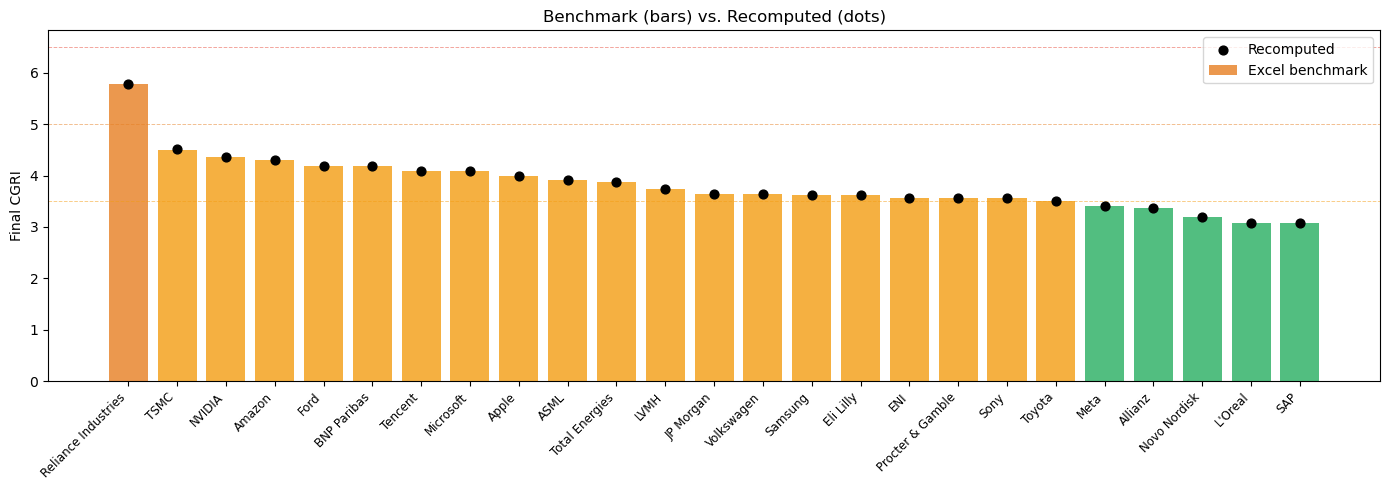

In [12]:
# 5b. Computed vs Excel validation (if all companies were computed)
if not results_df.empty:
    plot_df = results_df.sort_values('CGRI (Excel)', ascending=False)
    colors  = [risk_color(s) for s in plot_df['CGRI (Excel)']]
    fig, ax = plt.subplots(figsize=(14,5))
    ax.bar(range(len(plot_df)), plot_df['CGRI (Excel)'], color=colors, alpha=0.8, label='Excel benchmark')
    ax.scatter(range(len(plot_df)), plot_df['CGRI (computed)'], color='black', zorder=5, s=40, label='Recomputed')
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(plot_df['Company'], rotation=45, ha='right', fontsize=8.5)
    ax.set_ylabel('Final CGRI'); ax.set_title('Benchmark (bars) vs. Recomputed (dots)'); ax.legend()
    for y,c in [(3.5,'#f39c12'),(5.0,'#e67e22'),(6.5,'#e74c3c')]:
        ax.axhline(y,color=c,linestyle='--',linewidth=0.7,alpha=0.5)
    plt.tight_layout(); plt.show()
else:
    print('No recomputed results to plot.')

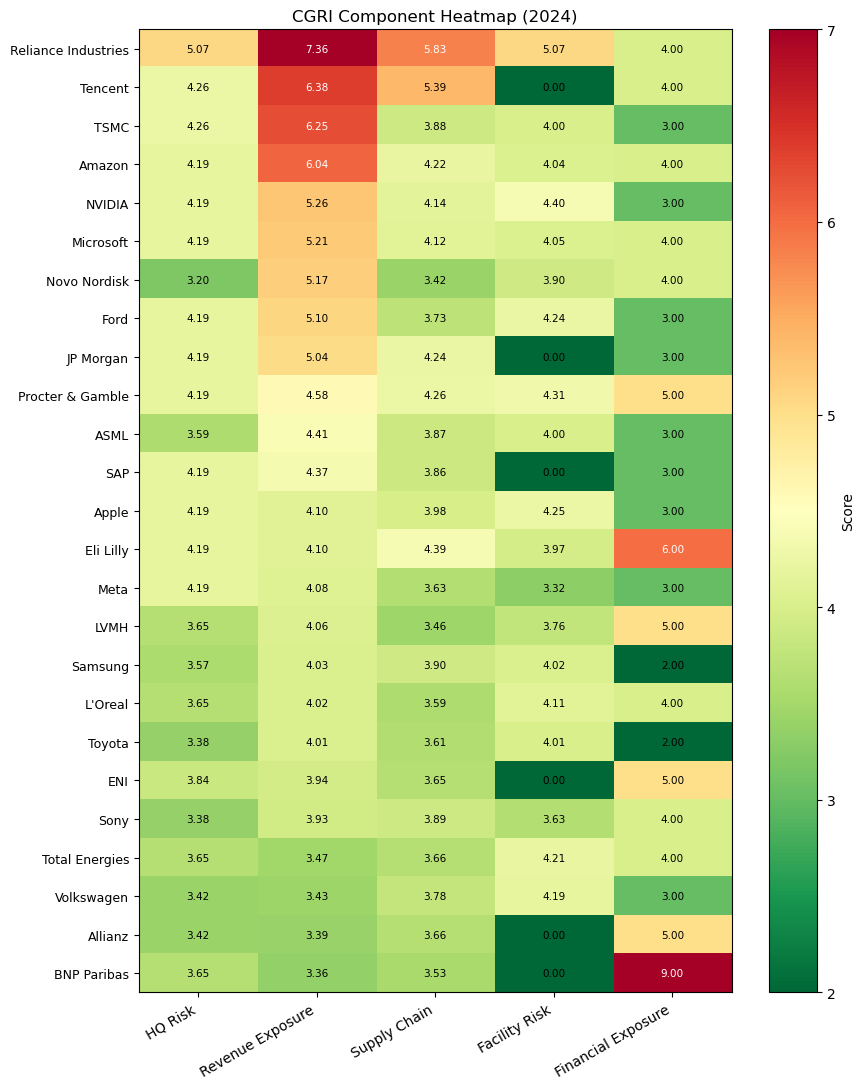

In [13]:
# 5c. Component heatmap
COMP_COLS = ['HQ Risk','Revenue Exposure','Supply Chain']
heat = bench_df.set_index('Company')[COMP_COLS].sort_values('Revenue Exposure',ascending=False)
fig, ax = plt.subplots(figsize=(9,11))
im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn_r', vmin=2, vmax=7)
ax.set_xticks(range(len(COMP_COLS))); ax.set_xticklabels(COMP_COLS, rotation=30, ha='right')
ax.set_yticks(range(len(heat)));      ax.set_yticklabels(heat.index, fontsize=9)
for i in range(len(heat)):
    for j in range(len(COMP_COLS)):
        v = heat.values[i,j]
        ax.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=7.5,
                color='white' if v>5.5 else 'black')
plt.colorbar(im, ax=ax, label='Score')
ax.set_title('CGRI Component Heatmap (2024)')
plt.tight_layout(); plt.show()

In [14]:
# 5d. Weighted stacked bar
wb2 = bench_df.copy().sort_values('Final CGRI', ascending=False)
wb2['HQ Risk (w)']      = 0.20*wb2['HQ Risk']
wb2['Revenue (w)']      = 0.40*wb2['Revenue Exposure']
wb2['Supply Chain (w)'] = 0.40*wb2['Supply Chain']
w_cols = ['HQ Risk (w)','Revenue (w)','Supply Chain (w)']
melted = wb2[['Company']+w_cols].melt(id_vars='Company',var_name='Component',value_name='Score')
fig = px.bar(melted, x='Company', y='Score', color='Component',
             title='Weighted Component Breakdown (pre-multiplier base)', height=480)
fig.update_layout(xaxis_tickangle=-40, barmode='stack')
fig.show()


## 6. Spider / Radar charts

The spider chart is the primary single-company output — it shows all five risk dimensions at once.

In [15]:
DIMS = ['HQ Risk','Revenue Exposure','Supply Chain']
PAL  = px.colors.qualitative.Plotly

def spider_chart(rows: list, title='') -> go.Figure:
    """
    rows : list of dicts with keys matching DIMS plus 'Company'.
    Returns a Plotly Figure with filled radar traces (one per company).
    """
    fig = go.Figure()
    for i, row in enumerate(rows):
        vals = [row[d] for d in DIMS]
        fig.add_trace(go.Scatterpolar(
            r     = vals + [vals[0]],
            theta = DIMS + [DIMS[0]],
            fill  = 'toself',
            name  = row.get('Company', f'#{i+1}'),
            line_color = PAL[i % len(PAL)],
            opacity    = 0.72,
        ))
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0,10])),
        showlegend=True, title=title, height=520,
        margin=dict(l=20,r=20,t=60,b=20),
    )
    return fig

print('spider_chart() defined.')

spider_chart() defined.


In [16]:
# Full portfolio spider
all_rows = bench_df[['Company']+DIMS].to_dict('records')
spider_chart(all_rows, 'Full portfolio — all 25 companies').show()

In [17]:
# Focused: select 5 companies for readable comparison
SELECTED = ['Amazon','Apple','TSMC','Reliance Industries','Novo Nordisk']
sel_rows = bench_df[bench_df['Company'].isin(SELECTED)][['Company']+DIMS].to_dict('records')
spider_chart(sel_rows, 'Selected companies — spider / radar comparison').show()

In [18]:
# Per-sector spider charts
for sector_name, group in bench_df.groupby('Sector'):
    rows = group[['Company']+DIMS].to_dict('records')
    spider_chart(rows, f'Sector: {sector_name}').show()

## 7. Custom company — full output with spider chart

Edit the `MY` dictionary below to analyse your own company.

In [19]:
# ═══════════════════════════════════════════════════════
# EDIT THIS BLOCK — replace with your company's data
# ═══════════════════════════════════════════════════════
MY = {
    'name':   'EuroIndustrial GmbH',
    'hq':     'Germany',
    'sector': 'Auto and commercial vehicle manufacturing',  # must match sector_mult keys
    'net_debt_ebitda': 1.8,

    # Enter % of revenues per country (any unit — auto-normalised to 100%)
    'revenue': {
        'Germany':30,'France':15,'United States':25,'China':20,'Brazil':5,'India':5,
    },
    # Supplier distribution
    'suppliers': {
        'Germany':40,'Czech Republic':20,'China':25,'Mexico':15,
    },
    # Supplier facility distribution
    'supplier_facilities': {
        'Germany':35,'Poland':20,'China':30,'Mexico':15,
    },
    # Own facility sites
    'facilities': {
        'Germany':50,'United States':20,'China':20,'Brazil':10,
    },
}
# ═══════════════════════════════════════════════════════
print('Available sectors:')
for s in sorted(sector_mult.keys()): print(' ', s)

Available sectors:
  Auto and commercial vehicle manufacturing
  Consumer durables
  Consumer staples and branded nondurables
  Financial services finance companies
  Insurance (Financial services)
  Oil and gas exploration and production
  Pharmaceuticals
  Retail and restaurants
  Technology hardware and semiconductors
  Technology software and services


In [20]:
res = compute_cgri(
    MY['hq'], MY['sector'], MY['net_debt_ebitda'],
    MY['revenue'], MY['suppliers'], MY['supplier_facilities']
)
cat = risk_label(res['final_cgri'])

print(f"{'='*52}")
print(f"  Company  : {MY['name']}")
print(f"  HQ       : {MY['hq']}")
print(f"  Sector   : {MY['sector']}")
print(f"{'='*52}")
print(f"  HQ Risk              : {res['hq_risk']:.4f}")
print(f"  Revenue Exposure     : {res['revenue_exposure']:.4f}  [HHI={res['rev_hhi']:.3f} -> x{res['rev_hhi_sub']}]")
print(f"  Supply Chain         : {res['supply_chain']:.4f}  [HHI={res['sc_hhi']:.3f} -> x{res['sc_hhi_sub']}]")
print(f"    sup component      : {res['sc_c_sup']:.4f}")
print(f"    supfac component   : {res['sc_c_fac']:.4f}")
print(f"    intermediate       : {res['sc_inter']:.4f}  (0.5 x A + 0.5 x B)")
print(f"  Financial Leverage   : x{res['financial_multiplier']}  (Net D/EBITDA={MY['net_debt_ebitda']})")
print(f"  Sector Multiplier    : x{res['sector_mult']:.2f}")
print(f"  Volatility Mult.     : x{res['vol_mult']:.4f}")
print(f"  Base score           : {res['base']:.4f}")
print(f"{'='*52}")
print(f"  FINAL CGRI           : {res['final_cgri']:.4f}  [{cat} Risk]")
print(f"{'='*52}")


  Company  : EuroIndustrial GmbH
  HQ       : Germany
  Sector   : Auto and commercial vehicle manufacturing
  HQ Risk              : 3.4200
  Revenue Exposure     : 3.9940  [HHI=0.220 -> x1.0]
  Supply Chain         : 4.5253  [HHI=0.280 -> x1.1]
    sup component      : 3.9960
    supfac component   : 4.1180
    intermediate       : 4.1139  (0.5 x A x 0.5 x B)
  Facility Risk        : 3.9350
  Financial Exposure   : 5  (Net D/E=1.8)
  Sector Multiplier    : x1.10
  Volatility Mult.     : x0.9348
  Base score           : 4.2331
  FINAL CGRI           : 4.3529  [Moderate Risk]


In [21]:
# Spider chart: custom company vs benchmark average
bench_avg = {d: bench_df[d].mean() for d in DIMS}
bench_avg['Company'] = 'Benchmark avg'

custom_row = {
    'Company':          MY['name'],
    'HQ Risk':          res['hq_risk'],
    'Revenue Exposure': res['revenue_exposure'],
    'Supply Chain':     res['supply_chain'],
}

spider_chart([custom_row, bench_avg],
             f"{MY['name']} vs Benchmark average — Spider chart").show()


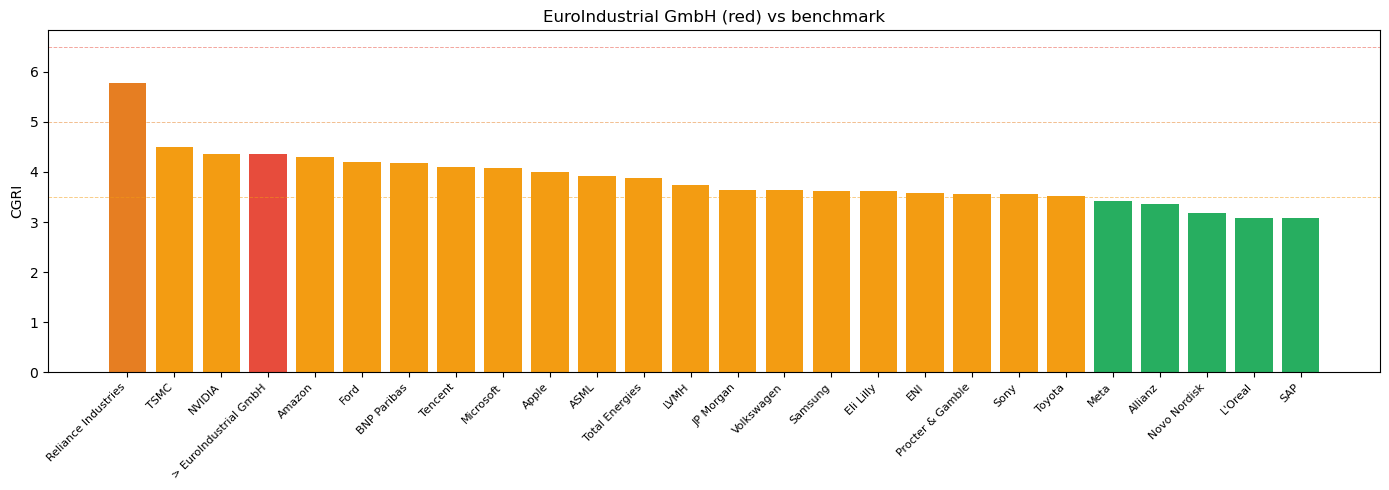

EuroIndustrial GmbH ranks #4 of 26. Category: Moderate


In [22]:
# Rank within benchmark + bar chart
rank_df = pd.concat([
    bench_df[['Company','Final CGRI','Risk Category']],
    pd.DataFrame([{'Company':f'> {MY["name"]}','Final CGRI':res['final_cgri'],'Risk Category':cat}])
], ignore_index=True).sort_values('Final CGRI', ascending=False).reset_index(drop=True)

colors = ['#e74c3c' if MY['name'] in c else risk_color(v)
          for c,v in zip(rank_df['Company'], rank_df['Final CGRI'])]

fig, ax = plt.subplots(figsize=(14,5))
ax.bar(range(len(rank_df)), rank_df['Final CGRI'], color=colors)
ax.set_xticks(range(len(rank_df)))
ax.set_xticklabels(rank_df['Company'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('CGRI'); ax.set_title(f"{MY['name']} (red) vs benchmark")
for y,c in [(3.5,'#f39c12'),(5.0,'#e67e22'),(6.5,'#e74c3c')]:
    ax.axhline(y,color=c,linestyle='--',linewidth=0.7,alpha=0.5)
plt.tight_layout(); plt.show()

pos = rank_df[rank_df['Company'].str.contains(MY['name'],regex=False)].index[0]+1
print(f"{MY['name']} ranks #{pos} of {len(rank_df)}. Category: {cat}")

In [23]:
# Detailed breakdown table
breakdown = pd.DataFrame([
    {'Component':'HQ Risk',          'Raw Score':res['hq_risk'],          'Weight':0.20,
     'HHI detail':'—'},
    {'Component':'Revenue Exposure', 'Raw Score':res['revenue_exposure'], 'Weight':0.40,
     'HHI detail':f"{res['rev_hhi']:.3f} -> x{res['rev_hhi_sub']}"},
    {'Component':'Supply Chain',     'Raw Score':res['supply_chain'],     'Weight':0.40,
     'HHI detail':f"{res['sc_hhi']:.3f} -> x{res['sc_hhi_sub']}"},
])
breakdown['Weighted'] = (breakdown['Raw Score']*breakdown['Weight']).round(4)
print(breakdown.to_string(index=False))
print(f"\nBase: {breakdown['Weighted'].sum():.4f}")
print(f"x Sector ({res['sector_mult']:.2f}) x Vol ({res['vol_mult']:.4f}) x FinLev ({res['financial_multiplier']}) = {res['final_cgri']:.4f} [{cat}]")


       Component  Raw Score  Weight    HHI detail  Weighted
         HQ Risk    3.42000    0.15             —    0.5130
Revenue Exposure    3.99400    0.25 0.220 -> x1.0    0.9985
    Supply Chain    4.52527    0.25 0.280 -> x1.1    1.1313
   Facility Risk    3.93500    0.15             —    0.5902
  Financial Exp.    5.00000    0.20             —    1.0000

Base: 4.2330
x Sector (1.10) x Vol (0.9348) = 4.3529 [Moderate]


## 8. Export results

In [24]:
out = NOTEBOOK_DIR / 'cgri_results_2024.csv'
if not results_df.empty:
    results_df.to_csv(out, index=False)
    print(f'Saved: {out}')
    results_df
else:
    print('results_df is empty — check errors above.')

Saved: /Users/arzumkarahan/Desktop/DSBA/2nd year/Geopolitics/Group Project/company-geopolitical-risk-index/notebooks/cgri_results_2024.csv
